<a href="https://colab.research.google.com/github/Alekhya-Vemireddy/NASSCOM/blob/main/U6_Probability_Statistics_Part2_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.1.3


In [ ]:
rolls = np.random.randint(1, 7, size=100_000)
p_even = (rolls % 2 == 0).mean()
p_gt4  = (rolls > 4).mean()
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')


P(even) ~ 0.502  (true 0.5)
P(>4)   ~ 0.334  (true 0.333)


In [ ]:
p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')


P(1) + P(2) = 0.334
P(1 or 2)   = 0.334  -> they match


In [ ]:
flips = np.random.randint(0, 2, size=(100_000, 2))
heads = flips.sum(axis=1)
p_both_heads = (heads == 2).mean()
print('P(both heads) =', round(p_both_heads, 3))
p_at_least_one_head = (heads >= 1).mean()
print('P(at least one head) =', round(p_at_least_one_head, 3))
print('P(0) + P(1) + P(2) =', round(p_both_heads + p_at_least_one_head, 3))



P(both heads) = 0.252
P(at least one head) = 0.749
P(0) + P(1) + P(2) = 1.001


In [ ]:
rolls = np.random.randint(1, 7, size=100_000)
even = rolls[rolls % 2 == 0]
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')

P(6 | even) ~ 0.332  (true 1/3)


In [ ]:
A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))



P(A)      = 0.498
P(A | B)  = 0.666
Independent? False


In [ ]:
rolls = np.random.randint(1, 7, size=100_000)
p_odd_given_lt4 = (rolls[rolls < 4] % 2 == 1).mean()
print('P(odd | roll < 4) ~', round(p_odd_given_lt4, 3), ' (true 0.5)')
p_lt4 = (rolls < 4).mean()
print('P(roll < 4)       =', round(p_lt4, 3))
p_odd = (rolls % 2 == 1).mean()
print('P(odd)            =', round(p_odd, 3))


P(odd | roll < 4) ~ 0.668  (true 0.5)
P(roll < 4)       = 0.499
P(odd)            = 0.503


In [ ]:
p_disease   = 0.01
p_pos_given_D  = 0.99
p_pos_given_nD = 0.01
p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)
p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')

P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [ ]:
N = 1_000_000
has_disease = np.random.rand(N) < p_disease
tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,
                     np.random.rand(N) < p_pos_given_nD)
among_positive = has_disease[tests_pos]
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))

Simulated P(sick | positive) = 0.503


In [ ]:
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham  = 0.05
p_free = p_free_given_spam * p_spam + p_free_given_ham * (1 - p_spam)
print('P(free) ~', round(p_free, 3))
p_spam_given_free = (p_free_given_spam * p_spam) / p_free
print('P(spam | free) ~', round(p_spam_given_free, 3))



P(free) ~ 0.16
P(spam | free) ~ 0.75


In [5]:
from scipy import stats

In [3]:
from scipy import stats
bern = stats.bernoulli(p=0.3).rvs(size=10_000)
print('Bernoulli(0.3) mean ~', round(bern.mean(), 3), '(true 0.3)')
pois = stats.poisson(mu=4).rvs(size=10_000)
print('Poisson(4) mean ~', round(pois.mean(), 3), '(true 4)')


Bernoulli(0.3) mean ~ 0.303 (true 0.3)
Poisson(4) mean ~ 4.009 (true 4)


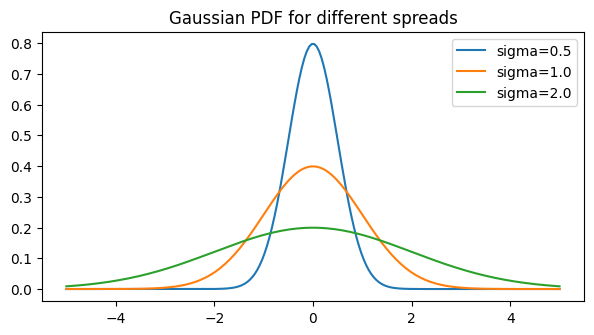

In [8]:
import numpy as np
import matplotlib.pyplot as plt
x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [0.5, 1.0, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for different spreads'); ax.legend(); plt.show()

Sample mean: 2.0215


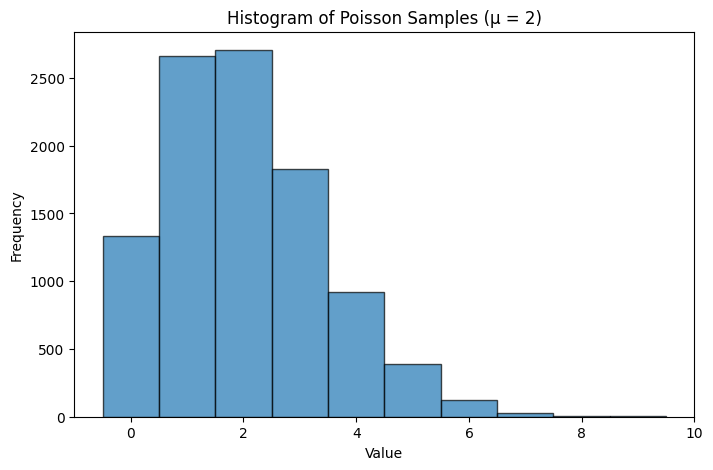

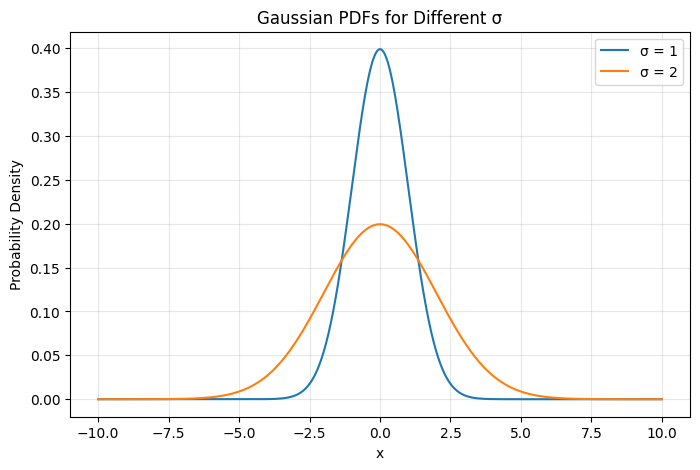

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Poisson(lam=2) samples + mean
samples = np.random.poisson(lam=2, size=10000)
sample_mean = np.mean(samples)

print("Sample mean:", sample_mean)

# 2. Histogram of the samples
plt.figure(figsize=(8, 5))
plt.hist(samples, bins=np.arange(samples.min(), samples.max() + 2) - 0.5,
         edgecolor='black', alpha=0.7)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Poisson Samples (μ = 2)")
plt.show()

# 3. Gaussian PDF for two sigmas on one plot
mu = 0
x = np.linspace(-10, 10, 1000)

sigma1 = 1
sigma2 = 2

pdf1 = norm.pdf(x, mu, sigma1)
pdf2 = norm.pdf(x, mu, sigma2)

plt.figure(figsize=(8, 5))
plt.plot(x, pdf1, label=f"σ = {sigma1}")
plt.plot(x, pdf2, label=f"σ = {sigma2}")

plt.xlabel("x")
plt.ylabel("Probability Density")
plt.title("Gaussian PDFs for Different σ")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [11]:
from scipy.stats import entropy
fair   = [0.5, 0.5]
biased = [0.9, 0.1]
certain= [1.0, 0.0]
print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')



Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits


In [12]:
P = np.array([0.5, 0.5])
Q = np.array([0.9, 0.1])
print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')
print('D(P || P) =', round(entropy(P, P, base=2), 3), '-> zero (identical)')
print('Note: D(P||Q) != D(Q||P)  ->', round(entropy(Q, P, base=2), 3), '(not symmetric)')


D(P || Q) = 0.737 bits
D(P || P) = 0.0 -> zero (identical)
Note: D(P||Q) != D(Q||P)  -> 0.531 (not symmetric)


In [13]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris

iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')

0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class


In [15]:
import numpy as np
from scipy.stats import entropy
# 1. Entropy of a fair 4-sided and 6-sided die (base=2)
fair_4 = [1/4] * 4
fair_6 = [1/6] * 6
H_4 = entropy(fair_4, base=2)
H_6 = entropy(fair_6, base=2)
print("Entropy of 4-sided die:", H_4, "bits")
print("Entropy of 6-sided die:", H_6, "bits")
# 2. KL divergence D(P || Q)
P = np.array([0.7, 0.3])
Q = np.array([0.5, 0.5])
KL_PQ = entropy(P, Q, base=2)
print("KL divergence D(P || Q):", KL_PQ, "bits")
# 3. Most / least informative iris feature (from 5C)

print("Most informative: Petal length")
print("Least informative: Sepal width")


Entropy of 4-sided die: 2.0 bits
Entropy of 6-sided die: 2.584962500721156 bits
KL divergence D(P || Q): 0.11870910076930725 bits
Most informative: Petal length
Least informative: Sepal width
